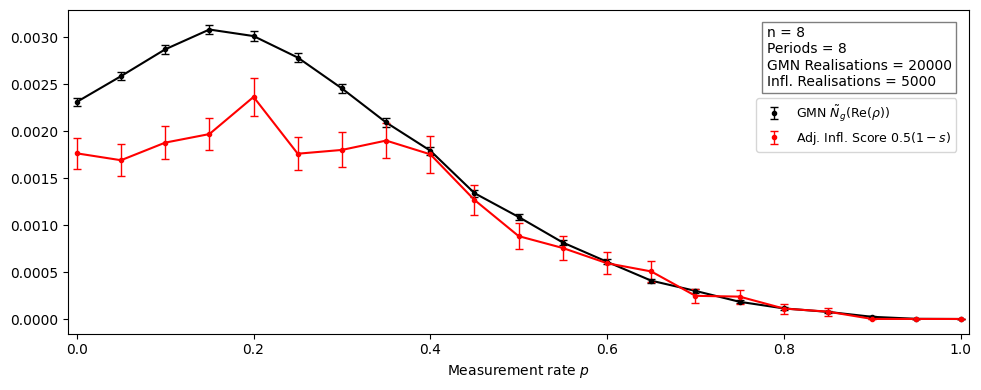

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# infl_reals = 5000

# # import GMN data
# df = pd.read_csv('data.csv')
# data_array = df.to_numpy().transpose()
# gmn_ps = data_array[0]
# gmn_vals = data_array[1]

# # import GMN/circuit info
# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()
# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

# # import inflation data
# df3 = pd.read_csv('cpp/inflation_n_8_real_5k_all.csv')
# data_array3 = df3.to_numpy().transpose()
# infl_ps = data_array3[0]
# # i_gmn_vals = data_array3[1]
# infl_scores = data_array3[2]



# # get means +/- stds for real GMN
# ps_unique = list(set(gmn_ps))
# gmn_means = []
# gmn_stds = []
# for p in ps_unique:
#     values_for_p = [val for val, p_val in zip(gmn_vals, gmn_ps) if p_val == p]
#     gmn_means.append(np.mean(values_for_p))
#     gmn_stds.append(np.std(values_for_p, ddof=1)/np.sqrt(realizations*n))

# # get means +/- stds for inflation
# infl_ps_unique = list(set(infl_ps))
# infl_means = []
# infl_stds = []
# for p in infl_ps_unique:
#     infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
#     infl_means.append(np.mean(infl_values_for_p))
#     infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

sorted_pairs = sorted(zip(infl_ps_unique, infl_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot inflation
scale = 0.5
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")
ax1.plot(x_sorted, [scale*(1-m) for m in y_sorted], color='red')


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations = {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax1.set_xlim(-0.01,1.01)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


In [7]:
import numpy as np
print(np.linspace(0.26, 0.36, 11))
# d = 4
# print(list(range(0, 2*d+1, d)))

[0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36]


Importing n = 16...
Importing n = 20...
Plotting...


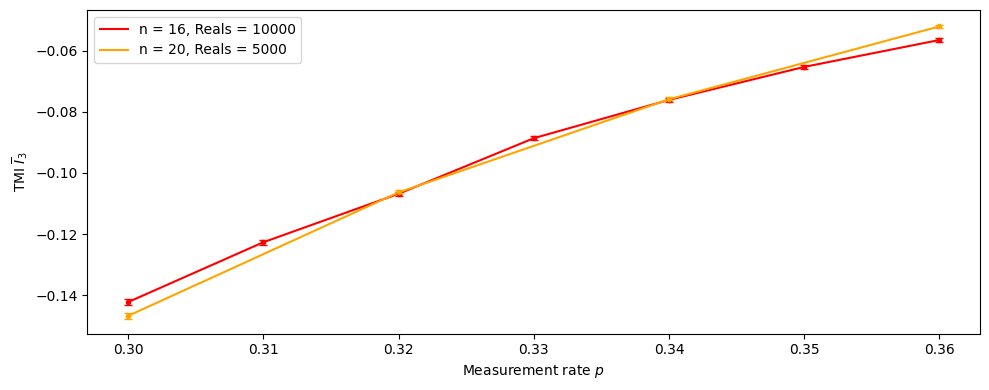

In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# -----------------------
# User controls
# -----------------------
P_MIN = 0.0
P_MAX = 0.36

CHUNKSIZE = 1_000_000  # increase/decrease depending on RAM

fermion = True
reduced_gate_set = False

if fermion:
	if reduced_gate_set:
		files = [
			"cpp/tmi_fermion2c_n_8_real_10000_0.18_0.28.csv",
			"cpp/tmi_fermion2c_n_12_real_10000_0.18_0.28.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_16_real_10000_0.18_0.28_res_21.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_20_real_2500_0.18_0.28_res_11.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_24_real_100_0.18_0.28_res_11.csv"
		]
		reals = [10000, 10000, 10000, 2500, 100]
		ns = [8, 12, 16, 20, 24]
    
	if not reduced_gate_set:
		files = [
            # "cpp/csv/tmi/fermion1c/tmi_fermion1c_n_12_real_7500_0.26_0.36_res_11.csv",
			"cpp/csv/tmi/fermion1c/tmi_fermion1c_n_16_real_10000_0.3_0.4_res_11.csv",
			"cpp/csv/tmi/fermion1c/tmi_fermion1c_n_20_real_5000_0.3_0.4_res_6.csv"
		]

		reals = [10000, 5000]
		ns = [16, 20]

if not fermion:
	files = [
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_12_real_5000_0.1_0.3_res_11.csv",
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_16_real_100_0.1_0.3_res_11.csv",
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_20_real_10_0.1_0.3_res_11.csv",
        "cpp/csv/tmi/qubitc/tmi_qubitc_n_24_real_10_0.1_0.3_res_11.csv"
	]

	reals = [5000, 100, 10, 10]
	ns = [12, 16, 20, 24]

colors = ["red", "orange", "green", "blue", "purple"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """

    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "tmi"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p")["tmi"].agg(
            count="count",
            sum="sum",
            sumsq=lambda x: np.square(x).sum(),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["sum"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    # sample variance: (sum(x^2) - sum(x)^2 / n) / (n - 1)
    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


ps_arr, mean_arr, std_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    ps_arr.append(ps)
    mean_arr.append(means)
    std_arr.append(stderrs)

print("Plotting...")

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

for i, n in enumerate(ns):
    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=std_arr[i],
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=colors[i],
        label=f"n = {n}, Reals = {reals[i]}",
    )

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"TMI $\overline{I}_3$")
ax1.legend()
fig.tight_layout()
plt.show()

Importing n = 16...
Plotting...


/tmp/ipykernel_354349/454034997.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


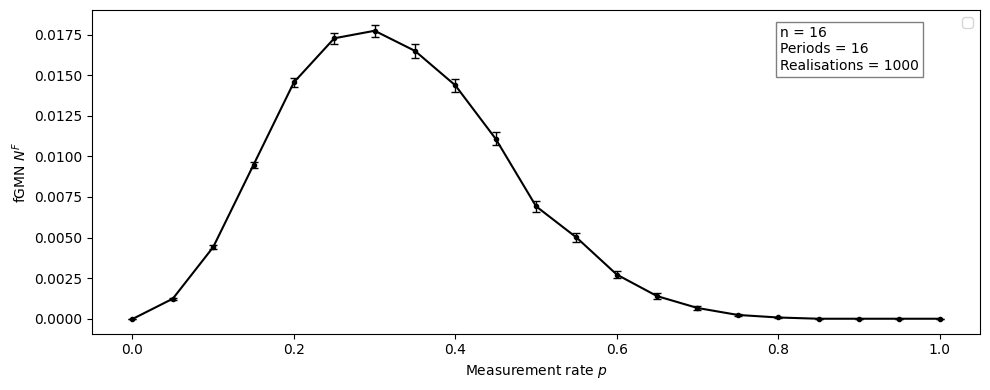

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# -----------------------
# User controls
# -----------------------
P_MIN = 0.0
P_MAX = 1.0

CHUNKSIZE = 1_000_000  # increase/decrease depending on RAM

# files = [
#     "csv/tmi/fermion2c/tmi_fermion2c_n_8_real_50k_0.1_0.5_res_81.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_12_real_25k_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_16_real_2500_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_20_real_250_0.1_0.5.csv",
# ]

files = [
    "cpp/fgmn_n_16_real_1k.csv"
]

ns = [16]
colors = ["black", "red", "orange", "green", "blue"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """

    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "fgmn"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p")["fgmn"].agg(
            count="count",
            sum="sum",
            sumsq=lambda x: np.square(x).sum(),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["sum"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    # sample variance: (sum(x^2) - sum(x)^2 / n) / (n - 1)
    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


ps_arr, mean_arr, std_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    ps_arr.append(ps)
    mean_arr.append(means)
    std_arr.append(stderrs)

print("Plotting...")

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

for i, n in enumerate(ns):
    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=std_arr[i],
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=colors[i],
    )

n = ns[0]
periods = ns[0]
realisations = 1000
props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"fGMN $N^F$")
ax1.legend()
fig.tight_layout()
plt.show()

Importing n = 8...
Importing n = 12...
Importing n = 16...
Preparing pyfssa arrays...
Common p grid has 11 points:
[0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4 ]
Fitting scaling collapse...
Fit success: True
p_c = 0.38182071 ± 0.0071
nu  = 2.2979226 ± 0.042
zeta = 0 fixed
collapse quality S = 1.4395983
S interpretation: S ~ 1: statistically reasonable collapse, assuming the standard errors and scaling ansatz are realistic.

Caveat: these are curvature/fit standard errors conditional on the selected finite-size scaling ansatz, p-window, system sizes, and standard errors. They do not include systematic uncertainty from finite-size corrections.
Plotting...


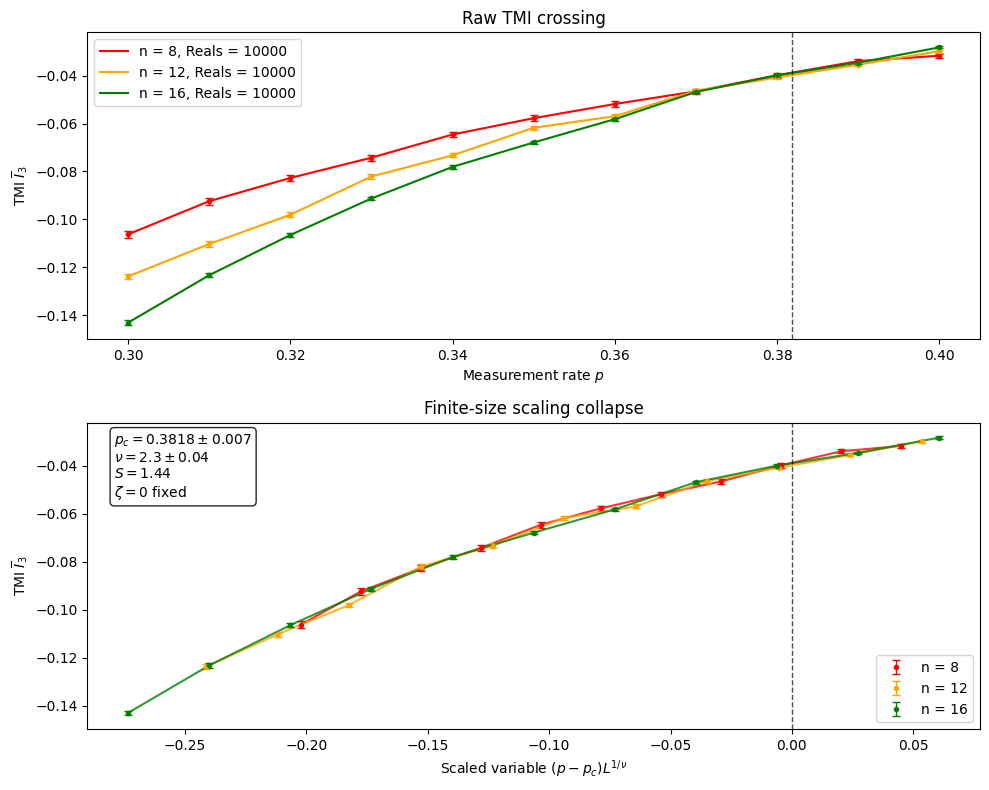

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import fssa
from scipy.optimize import minimize

# Compatibility patch for older pyfssa versions on NumPy >= 1.24
if not hasattr(np, "int"):
    np.int = int

# -----------------------
# User controls
# -----------------------
P_MIN = 0.29
P_MAX = 0.41

CHUNKSIZE = 1_000_000
P_ROUND_DECIMALS = 12

circ_type = "qrppu"

if circ_type == "mms":
    PC0 = 0.17
if circ_type == "rfgs":
    PC0 = 0.26
if circ_type == "qrppu" or circ_type == "rppu":
    PC0 = 0.33


NU0 = 2.0           # initial guess for nu
ZETA0 = 0.0         # TMI is dimensionless, so zeta=0 is the usual default
FIT_ZETA = False    # True => use fssa.autoscale and fit p_c, nu, zeta
X_BOUNDS = None     # optionally e.g. (-1.5, 1.5) to fit only central collapse region
ERR_FLOOR = 1e-12   # pyfssa requires strictly positive standard errors

# Curvature-error controls
CURVATURE_REL_STEP = 1e-3


if circ_type == "mms":
    files = [
    "cpp/csv/tmi/qubitc/tmi_qubitc_n_12_real_5000_0.1_0.3_res_11.csv",
    "cpp/csv/tmi/qubitc/tmi_qubitc_n_16_real_100_0.1_0.3_res_11.csv",
    "cpp/csv/tmi/qubitc/tmi_qubitc_n_20_real_10_0.1_0.3_res_11.csv",
    "cpp/csv/tmi/qubitc/tmi_qubitc_n_24_real_10_0.1_0.3_res_11.csv",
    ]

    reals = [5000, 100, 10, 10]
    ns = [12, 16, 20, 24]
if circ_type == "rfgs":
    # files = [
    # "cpp/tmi_fermion2c_n_8_real_10000_0.18_0.28.csv",
    # "cpp/tmi_fermion2c_n_12_real_10000_0.18_0.28.csv",
    # "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_16_real_10000_0.18_0.28_res_21.csv",
    # "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_20_real_2500_0.18_0.28_res_11.csv",
    # # "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_24_real_100_0.18_0.28_res_11.csv",
    # ]
    # reals = [10000, 10000, 10000, 2500]#, 100]
    # ns = [8, 12, 16, 20]#, 24]

    files = [
    # "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_8_real_10000_0.2_0.4_res_11.csv",
    "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_12_real_10000_0.3_0.5_res_11.csv",
    "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_16_real_10000_0.3_0.5_res_11.csv",
    "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_20_real_1000_0.3_0.5_res_11.csv"
    ]
    reals = [10000, 10000, 1000]
    ns = [12, 16, 20]
if circ_type == "qrppu":
    files = [
    "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_8_real_10000_0.3_0.4_res_11.csv",
    "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_12_real_10000_0.3_0.4_res_11.csv",
    "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_16_real_10000_0.3_0.4_res_11.csv",
    # "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_20_real_1000_0.3_0.4_res_11.csv"
    ]

    reals = [10000, 10000, 10000]#, 1000]
    ns = [8, 12, 16]#, 20]
if circ_type == "rppu":
    files = [
    # "cpp/csv/tmi/fermion1c/tmi_fermion2c_n_12_real_50000_0.3_0.5_res_6.csv",
    "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv",
    "old_cpp/csv/tmi/fermion1c/tmi_fermion1c_n_20_real_2500_0.3_0.4_res_6.csv",
    "old_cpp/csv/tmi/fermion1c/tmi_fermion1c_n_24_real_500_0.3_0.36_res_4.csv"
    ]

    reals = [20_000, 2500, 500]
    ns = [16, 20, 24]

    # files = [
    # 	# "cpp/csv/tmi/fermion1c/periods_eq_n/tmi_fermion1c_n_8_real_10000_0.3_0.4_res_11.csv",
    #     "cpp/csv/tmi/fermion1c/periods_eq_n/tmi_fermion1c_n_12_real_10000_0.3_0.4_res_11.csv",
    #     "cpp/csv/tmi/fermion1c/periods_eq_n/tmi_fermion1c_n_16_real_10000_0.3_0.4_res_11.csv",
    #     "cpp/csv/tmi/fermion1c/periods_eq_n/tmi_fermion1c_n_20_real_5000_0.3_0.4_res_6.csv",
    # ]

    # reals = [10000, 10000, 5000]
    # ns = [12, 16, 20]


assert len(files) == len(ns) == len(reals), "files, ns, and reals must have the same length."

colors = ["red", "orange", "green", "blue", "purple", "brown", "black"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
	"""
	Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

	Expected CSV columns:
	p,tmi
	"""
	partials = []

	for chunk in pd.read_csv(path, usecols=["p", "tmi"], chunksize=chunksize):
		if p_min is not None:
			chunk = chunk[chunk["p"] >= p_min]
		if p_max is not None:
			chunk = chunk[chunk["p"] <= p_max]

		chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna(subset=["p", "tmi"])

		if chunk.empty:
			continue

	chunk["tmi2"] = chunk["tmi"] * chunk["tmi"]

	grouped = chunk.groupby("p").agg(
		count=("tmi", "count"),
		total=("tmi", "sum"),
		sumsq=("tmi2", "sum"),
	)

	partials.append(grouped)

	if not partials:
		return np.array([]), np.array([]), np.array([])

	combined = pd.concat(partials).groupby(level=0).sum().sort_index()

	count = combined["count"].to_numpy(dtype=float)
	total = combined["total"].to_numpy(dtype=float)
	sumsq = combined["sumsq"].to_numpy(dtype=float)

	means = total / count

	variances = np.full_like(means, np.nan, dtype=float)
	valid = count > 1
	variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

	stds = np.sqrt(np.maximum(variances, 0.0))
	stderrs = stds / np.sqrt(count)

	ps = combined.index.to_numpy(dtype=float)

	# if fermion and reduced_gate_set:
	# 	ps = 1 - np.sqrt(1 - ps)

	return ps, means, stderrs


def align_on_common_p_grid(ps_arr, mean_arr, stderr_arr, round_decimals=12):
    """
    pyfssa requires the same p grid for every system size.
    This function keeps only p values present in every dataset.
    """
    rounded_ps_arr = [np.round(ps, round_decimals) for ps in ps_arr]

    common = set(rounded_ps_arr[0])
    for ps in rounded_ps_arr[1:]:
        common &= set(ps)

    common = np.array(sorted(common), dtype=float)

    if common.size < 4:
        raise RuntimeError(
            f"Only found {common.size} common p values across all sizes. "
            "pyfssa needs a rectangular grid. Either restrict files to matching p grids "
            "or interpolate onto a common grid before collapse."
        )

    a_rows = []
    da_rows = []

    for ps, means, stderrs in zip(rounded_ps_arr, mean_arr, stderr_arr):
        mean_lookup = dict(zip(ps, means))
        stderr_lookup = dict(zip(ps, stderrs))

        a_rows.append([mean_lookup[p] for p in common])
        da_rows.append([stderr_lookup[p] for p in common])

    rho = common
    a = np.asarray(a_rows, dtype=float)
    da = np.asarray(da_rows, dtype=float)

    # pyfssa.quality requires strictly positive dy values.
    da = np.where(np.isfinite(da) & (da > 0.0), da, ERR_FLOOR)

    return rho, a, da


def estimate_errors_from_curvature(objective, theta_hat, f_min=None, rel_step=1e-3):
    """
    Estimate parameter standard errors from the local curvature of the collapse
    quality S near the optimum.

    This gives curvature/fit errors conditional on:
        - the finite-size scaling ansatz,
        - the selected p-window,
        - included system sizes,
        - the supplied standard errors,
        - and, if FIT_ZETA=False, fixed zeta.

    It does not include systematic uncertainty from finite-size corrections.
    """
    theta_hat = np.asarray(theta_hat, dtype=float)
    n_params = theta_hat.size

    if f_min is None:
        f_min = objective(theta_hat)

    steps = rel_step * np.maximum(np.abs(theta_hat), 1.0)

    hessian = np.zeros((n_params, n_params), dtype=float)

    def safe_eval(x):
        val = objective(x)
        if not np.isfinite(val):
            return np.inf
        return val

    # Diagonal second derivatives
    for i in range(n_params):
        step = steps[i]

        for _ in range(12):
            xp = theta_hat.copy()
            xm = theta_hat.copy()

            xp[i] += step
            xm[i] -= step

            fp = safe_eval(xp)
            fm = safe_eval(xm)

            if np.isfinite(fp) and np.isfinite(fm):
                break

            step *= 0.5

        if not (np.isfinite(fp) and np.isfinite(fm)):
            hessian[i, i] = np.nan
        else:
            hessian[i, i] = (fp - 2.0 * f_min + fm) / step ** 2

    # Off-diagonal mixed derivatives
    for i in range(n_params):
        for j in range(i + 1, n_params):
            step_i = steps[i]
            step_j = steps[j]

            for _ in range(12):
                xpp = theta_hat.copy()
                xpm = theta_hat.copy()
                xmp = theta_hat.copy()
                xmm = theta_hat.copy()

                xpp[i] += step_i
                xpp[j] += step_j

                xpm[i] += step_i
                xpm[j] -= step_j

                xmp[i] -= step_i
                xmp[j] += step_j

                xmm[i] -= step_i
                xmm[j] -= step_j

                fpp = safe_eval(xpp)
                fpm = safe_eval(xpm)
                fmp = safe_eval(xmp)
                fmm = safe_eval(xmm)

                if all(np.isfinite(v) for v in [fpp, fpm, fmp, fmm]):
                    break

                step_i *= 0.5
                step_j *= 0.5

            if not all(np.isfinite(v) for v in [fpp, fpm, fmp, fmm]):
                hessian[i, j] = np.nan
                hessian[j, i] = np.nan
            else:
                hessian[i, j] = (fpp - fpm - fmp + fmm) / (4.0 * step_i * step_j)
                hessian[j, i] = hessian[i, j]

    if not np.all(np.isfinite(hessian)):
        errors = np.full(n_params, np.nan)
        varco = np.full((n_params, n_params), np.nan)
        return errors, varco, hessian

    try:
        # pyfssa-style reduced-chi-square curvature convention.
        varco = 2.0 * f_min * np.linalg.inv(hessian)
    except np.linalg.LinAlgError:
        varco = 2.0 * f_min * np.linalg.pinv(hessian)

    diag = np.diag(varco)
    errors = np.sqrt(np.where(diag >= 0.0, diag, np.nan))

    return errors, varco, hessian


def fit_collapse_fixed_zeta(l, rho, a, da, pc0, nu0, zeta=0.0, x_bounds=None):
    """
    Fit only p_c and nu, keeping zeta fixed.
    Also reports curvature-estimated standard errors for p_c and nu.
    """
    def objective(params):
        pc, nu = params

        if not np.isfinite(pc) or not np.isfinite(nu):
            return np.inf
        if nu <= 0.0:
            return np.inf
        if pc < rho.min() or pc > rho.max():
            return np.inf

        scaled = fssa.scaledata(
            l=l,
            rho=rho,
            a=a,
            da=da,
            rho_c=pc,
            nu=nu,
            zeta=zeta,
        )

        q = fssa.quality(scaled.x, scaled.y, scaled.dy, x_bounds=x_bounds)

        if not np.isfinite(q):
            return np.inf

        return q

    res = minimize(
        objective,
        x0=np.array([pc0, nu0], dtype=float),
        method="Nelder-Mead",
        options={
            "xatol": 1e-8,
            "fatol": 1e-8,
            "maxiter": 20_000,
            "maxfev": 20_000,
        },
    )

    pc_fit, nu_fit = res.x
    q_fit = objective(res.x)

    errors, varco, hessian = estimate_errors_from_curvature(
        objective=objective,
        theta_hat=res.x,
        f_min=q_fit,
        rel_step=CURVATURE_REL_STEP,
    )

    return {
        "success": res.success,
        "message": res.message,
        "rho": pc_fit,
        "nu": nu_fit,
        "zeta": zeta,
        "drho": errors[0],
        "dnu": errors[1],
        "dzeta": 0.0,
        "errors": errors,
        "varco": varco,
        "hessian": hessian,
        "quality": q_fit,
        "raw_result": res,
    }


def classify_collapse_quality(S):
    """
    Practical interpretation of pyfssa's reduced-chi-square-like quality S.
    """
    if not np.isfinite(S):
        return "S is non-finite: the collapse fit failed or produced invalid scaled data."
    if S < 0.5:
        return (
            "S << 1: suspiciously good collapse. Error bars may be overestimated, "
            "data may be correlated, or the fit window may be too forgiving."
        )
    if S < 2.0:
        return (
            "S ~ 1: statistically reasonable collapse, assuming the standard errors "
            "and scaling ansatz are realistic."
        )
    if S < 5.0:
        return (
            "S = 2–5: marginal collapse. The result may be useful, but corrections "
            "to scaling, underestimated errors, or an overly broad p-window are likely."
        )
    if S < 10.0:
        return (
            "S = 5–10: poor collapse. Treat p_c and nu cautiously; try changing "
            "X_BOUNDS, excluding small N, or adding more data."
        )
    return (
        "S >> 10: very poor collapse under the assumed ansatz. The fitted p_c and "
        "nu should not be trusted without further checks."
    )


ps_arr, mean_arr, stderr_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    if ps.size == 0:
        raise RuntimeError(f"No usable data loaded for n = {n} from {path}")

    ps_arr.append(ps)
    mean_arr.append(means)
    stderr_arr.append(stderrs)

print("Preparing pyfssa arrays...")

l = np.asarray(ns, dtype=float)
rho, a, da = align_on_common_p_grid(
    ps_arr,
    mean_arr,
    stderr_arr,
    round_decimals=P_ROUND_DECIMALS,
)

print(f"Common p grid has {rho.size} points:")
print(rho)

print("Fitting scaling collapse...")

if FIT_ZETA:
    # pyfssa.autoscale fits p_c, nu, and zeta.
    res = fssa.autoscale(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c0=PC0,
        nu0=NU0,
        zeta0=ZETA0,
        x_bounds=X_BOUNDS,
    )

    pc_fit = res["rho"]
    nu_fit = res["nu"]
    zeta_fit = res["zeta"]

    dpc_fit = res["drho"]
    dnu_fit = res["dnu"]
    dzeta_fit = res["dzeta"]

    scaled = fssa.scaledata(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c=pc_fit,
        nu=nu_fit,
        zeta=zeta_fit,
    )

    collapse_quality = fssa.quality(
        scaled.x,
        scaled.y,
        scaled.dy,
        x_bounds=X_BOUNDS,
    )

    fit_success = res["success"]

else:
    # Better default for TMI: fit p_c and nu, keep zeta = 0.
    res = fit_collapse_fixed_zeta(
        l=l,
        rho=rho,
        a=a,
        da=da,
        pc0=PC0,
        nu0=NU0,
        zeta=ZETA0,
        x_bounds=X_BOUNDS,
    )

    pc_fit = res["rho"]
    nu_fit = res["nu"]
    zeta_fit = res["zeta"]

    dpc_fit = res["drho"]
    dnu_fit = res["dnu"]
    dzeta_fit = res["dzeta"]

    collapse_quality = res["quality"]
    fit_success = res["success"]

    scaled = fssa.scaledata(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c=pc_fit,
        nu=nu_fit,
        zeta=zeta_fit,
    )

S_interpretation = classify_collapse_quality(collapse_quality)

print("Fit success:", fit_success)
print(f"p_c = {pc_fit:.8g} ± {dpc_fit:.2g}")
print(f"nu  = {nu_fit:.8g} ± {dnu_fit:.2g}")

if FIT_ZETA:
    print(f"zeta = {zeta_fit:.8g} ± {dzeta_fit:.2g}")
else:
    print(f"zeta = {zeta_fit:.8g} fixed")

print(f"collapse quality S = {collapse_quality:.8g}")
print("S interpretation:", S_interpretation)
print()
print(
    "Caveat: these are curvature/fit standard errors conditional on the selected "
    "finite-size scaling ansatz, p-window, system sizes, and standard errors. "
    "They do not include systematic uncertainty from finite-size corrections."
)

print("Plotting...")

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [1.0, 1.0]},
)

# -----------------------
# Top subplot: raw TMI crossing
# -----------------------
for i, n in enumerate(ns):
    c = colors[i % len(colors)]

    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=stderr_arr[i],
        fmt=".",
        color=c,
        ecolor=c,
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=c,
        label=f"n = {n}, Reals = {reals[i]}",
    )

ax1.axvline(pc_fit, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"TMI $\overline{I}_3$")
ax1.set_title("Raw TMI crossing")
ax1.legend()

# -----------------------
# Bottom subplot: scaling collapse
# -----------------------
for i, n in enumerate(ns):
    c = colors[i % len(colors)]

    ax2.errorbar(
        scaled.x[i],
        scaled.y[i],
        yerr=scaled.dy[i],
        fmt=".",
        color=c,
        ecolor=c,
        capsize=3,
        elinewidth=1,
        label=f"n = {n}",
    )

    ax2.plot(
        scaled.x[i],
        scaled.y[i],
        color=c,
        alpha=0.8,
    )

ax2.axvline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax2.set_xlabel(r"Scaled variable $(p - p_c)L^{1/\nu}$")
ax2.set_ylabel(
    r"Scaled TMI $L^{-\zeta/\nu}\overline{I}_3$"
    if FIT_ZETA
    else r"TMI $\overline{I}_3$"
)
ax2.set_title("Finite-size scaling collapse")
ax2.legend()

textbox = (
    rf"$p_c = {pc_fit:.4g} \pm {dpc_fit:.1g}$" "\n"
    rf"$\nu = {nu_fit:.3g} \pm {dnu_fit:.1g}$" "\n"
    rf"$S = {collapse_quality:.3g}$"
)

if FIT_ZETA:
    textbox += "\n" + rf"$\zeta = {zeta_fit:.3g} \pm {dzeta_fit:.1g}$"
else:
    textbox += "\n" + rf"$\zeta = 0$ fixed"

ax2.text(
    0.03,
    0.97,
    textbox,
    transform=ax2.transAxes,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.85,
    ),
)

fig.tight_layout()
plt.show()

In [67]:
import numpy as np
print(np.linspace(0.3, 0.36, 13))

[0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36 ]


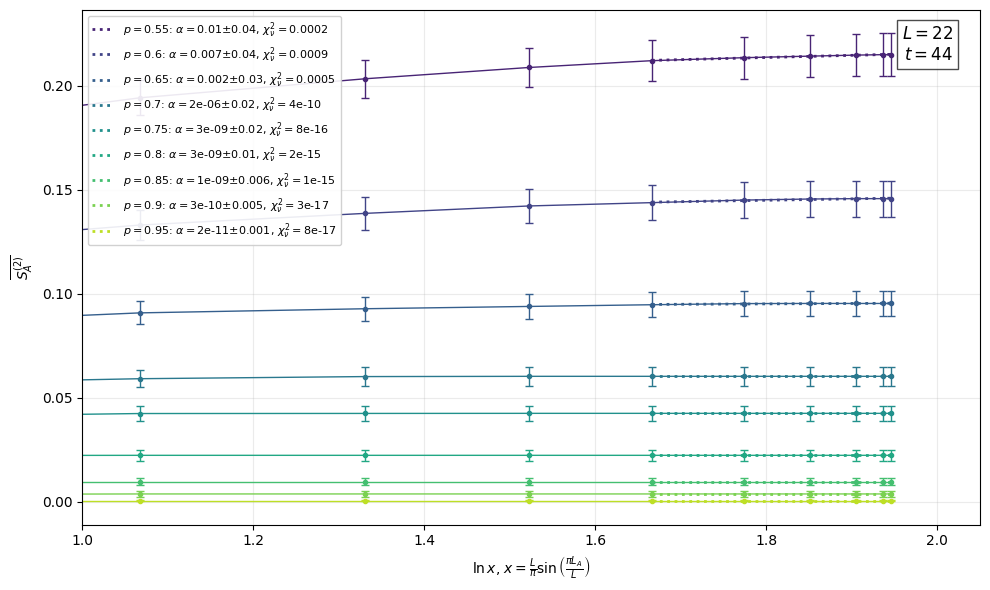

In [59]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# User options
# ---------------------------------------------------------------------------

files = [
    Path(f"cpp/csv/entropy/n22/run1/entropy_n22_p{p}_circ2.csv")
    for p in ["0.55", "0.60", "0.65", "0.70", "0.75", "0.80", "0.85", "0.9", "0.95"]
]

# Only fit curves whose measurement rate is strictly greater than this value.
# Change ">" to ">=" below if the threshold itself should be included.
above_p = 0.3

# Exclude the first k points, ordered by increasing L_A, from each linear fit.
exclude_first_k_pts = 4

# S2_stderr is appropriate for uncertainty-weighted fits to the ensemble mean.
# S2_stddev instead represents trajectory-to-trajectory spread.
uncertainty_column = "S2_stderr"


# ---------------------------------------------------------------------------
# Weighted linear fit
# ---------------------------------------------------------------------------

def weighted_linear_fit(x, y, sigma):
    """
    Fit y = m*x + b using absolute uncertainties sigma.

    Returns
    -------
    m, b, m_stderr, b_stderr, reduced_chi_squared
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0.0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if x.size < 3:
        raise ValueError(
            "At least three valid points are required to calculate "
            "a linear fit and reduced chi-squared."
        )

    # Design matrix for y = m*x + b.
    design = np.column_stack((x, np.ones_like(x)))
    weights = 1.0 / sigma**2

    normal_matrix = design.T @ (weights[:, None] * design)

    try:
        covariance = np.linalg.inv(normal_matrix)
    except np.linalg.LinAlgError as exc:
        raise ValueError("Linear-fit covariance matrix is singular.") from exc

    parameters = covariance @ (design.T @ (weights * y))
    slope, intercept = parameters

    fitted_y = slope * x + intercept
    chi_squared = np.sum(((y - fitted_y) / sigma) ** 2)

    degrees_of_freedom = x.size - 2
    reduced_chi_squared = chi_squared / degrees_of_freedom

    slope_stderr = np.sqrt(covariance[0, 0])
    intercept_stderr = np.sqrt(covariance[1, 1])

    return (
        slope,
        intercept,
        slope_stderr,
        intercept_stderr,
        reduced_chi_squared,
    )


# ---------------------------------------------------------------------------
# Read files
# ---------------------------------------------------------------------------

ln_x_arr = []
mean_arr = []
std_arr = []

ns = []
periods_arr = []
ps_arr = []
realisations_arr = []
circ_types = []
circuit_names = []

for file in files:
    df = pd.read_csv(file)

    required_columns = {
        "N",
        "periods",
        "p",
        "completed_realizations",
        "circ_type",
        "circuit_name",
        "L_A",
        "ln_x",
        "S2_mean",
        uncertainty_column,
    }

    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(
            f"{file} is missing required columns: {sorted(missing)}"
        )

    # For L_A <= L/2, sorting by L_A also sorts ln(x) monotonically.
    df = df.sort_values("L_A").reset_index(drop=True)

    ln_x_arr.append(df["ln_x"].to_numpy(dtype=float))
    mean_arr.append(df["S2_mean"].to_numpy(dtype=float))
    std_arr.append(df[uncertainty_column].to_numpy(dtype=float))

    ns.append(int(df["N"].iloc[0]))
    periods_arr.append(int(df["periods"].iloc[0]))
    ps_arr.append(float(df["p"].iloc[0]))
    realisations_arr.append(int(df["completed_realizations"].iloc[0]))
    circ_types.append(int(df["circ_type"].iloc[0]))
    circuit_names.append(str(df["circuit_name"].iloc[0]))


# Check that the compact metadata box is meaningful.
unique_ns = sorted(set(ns))
unique_periods = sorted(set(periods_arr))

if len(unique_ns) != 1:
    raise ValueError(
        f"Input CSVs do not all have the same L=N: {unique_ns}"
    )

if len(unique_periods) != 1:
    raise ValueError(
        f"Input CSVs do not all have the same t=periods: {unique_periods}"
    )


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(files))
)

for i, file in enumerate(files):
    x = ln_x_arr[i]
    y = mean_arr[i]
    yerr = std_arr[i]
    p = ps_arr[i]

    # Plot simulation data.
    ax1.errorbar(
        x,
        y,
        yerr=yerr,
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
        label="_nolegend_",
    )

    # Connecting line through all simulation points.
    data_line, = ax1.plot(
        x,
        y,
        color=colors[i],
        linewidth=1,
        label="_nolegend_",
    )

    if p > above_p:
        if exclude_first_k_pts < 0:
            raise ValueError("exclude_first_k_pts must be nonnegative.")

        fit_x = x[exclude_first_k_pts:]
        fit_y = y[exclude_first_k_pts:]
        fit_sigma = yerr[exclude_first_k_pts:]

        try:
            (
                slope,
                intercept,
                slope_stderr,
                intercept_stderr,
                reduced_chi_squared,
            ) = weighted_linear_fit(
                fit_x,
                fit_y,
                fit_sigma,
            )

            # Draw the fit only across the fitted data interval.
            fit_x_line = np.linspace(
                np.min(fit_x),
                np.max(fit_x),
                200,
            )
            fit_y_line = slope * fit_x_line + intercept

            fit_label = (
                rf"$p={p:g}$: "
                rf"$\alpha=${slope:.1g}$\pm${slope_stderr:.1g}, "
                rf"$\chi_\nu^2=${reduced_chi_squared:.1g}"
            )

            ax1.plot(
                fit_x_line,
                fit_y_line,
                linestyle=":",
                linewidth=2,
                color=colors[i],
                label=fit_label,
            )

        except ValueError as exc:
            # Retain the curve in the legend when too few valid fit points exist.
            data_line.set_label(
                rf"$p={p:g}$: fit unavailable ({exc})"
            )

    else:
        # Curves below the threshold are shown but not fitted.
        data_line.set_label(
            rf"$p={p:g}$"
        )


# ---------------------------------------------------------------------------
# Compact run metadata
# ---------------------------------------------------------------------------

metadata_text = (
    rf"$L={unique_ns[0]}$"
    "\n"
    rf"$t={unique_periods[0]}$"
)

props = {
    "boxstyle": "square",
    "facecolor": "white",
    "alpha": 0.7,
}

ax1.text(
    0.97,
    0.97,
    metadata_text,
    transform=ax1.transAxes,
    fontsize=12,
    horizontalalignment="right",
    verticalalignment="top",
    bbox=props,
)


# ---------------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------------

ax1.set_xlabel(
    r"$\ln x$, "
    r"$x=\frac{L}{\pi}\sin\left(\frac{\pi L_A}{L}\right)$"
)
ax1.set_ylabel(r"$\overline{S_A^{(2)}}$")

ax1.legend(
    fontsize=8,
    framealpha=0.9,
    loc="upper left",
)

ax1.grid(alpha=0.25)
# ax1.set_ylim(-0.05, 2.25)
ax1.set_xlim(1.0, 2.05)

fig.tight_layout()
plt.show()